In [17]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import mesa
import pandas as pd

from mesa.visualization import SolaraViz, make_plot_component, make_space_component


In [52]:
def update_expectation(expected_outcome, outcome, alpha):
    expected_outcome += alpha * (outcome - expected_outcome)
    return expected_outcome



class AdoptionAgent(mesa.Agent):
    """An agent with skill, and the ability to use collective intelligence."""

    def __init__(self, model):
        """initialize an AdoptionAgent instance.

        Args:
            model: A model instance
        """
        super().__init__(model)
        
        "Preset starting variables for the model:"
        self.skill = np.clip(np.random.normal(loc=0.5, scale=0.2), 0, 1)
        self.ability = 0
        self.wins = 1
        self.losses = 1
        self.aichoice = 0
        self.expected = 0.5
        self.outcome = 0
        self.luck = 0

        "Variables that can be changed between batches:"
        self.alpha = 0.3
        self.beta = 0.2
        self.boost = 0
        self.middle = 0
        self.scaler = 0.02
        


    def move(self):
        """move to a random neighboring cell."""
        possible_steps = self.model.grid.get_neighborhood(
            self.pos, moore=True, include_center=False
        )
        new_position = self.random.choice(possible_steps)
        self.model.grid.move_agent(self, new_position)

    def compete(self):
        """One agent picks another agent randomly and compares scores updating all info"""
        cellmates = self.model.grid.get_cell_list_contents([self.pos])
        if len(cellmates) > 1:
            other = self.random.choice(cellmates)


            self.aichoice = np.random.choice([0, 1], p=[1 - self.expected, self.expected])
            other.aichoice = np.random.choice([0, 1], p=[1 - other.expected, other.expected])

            self.luck = np.random.normal(loc= self.middle , scale= self.scaler )
            other.luck = np.random.normal(loc= self.middle , scale= self.scaler )

            self.ability = self.skill + self.aichoice * self.boost + self.luck
            other.ability = other.skill + other.aichoice * other.boost + other.luck
            self.skill = np.clip(self.skill + ((-1)**self.aichoice ) * self.beta, 0, 1)
            if self.ability > other.ability:
                self.wins += 1
                self.outcome = 1 * self.aichoice
                self.expected = update_expectation(self.expected, self.outcome, self.alpha)

            else:
                self.losses += 1
                self.outcome = 1
                self.expected = update_expectation(self.expected, self.outcome, self.alpha)




    def step(self):
        """do one step of the agent."""
        self.move()
        self.compete()


class AdoptionModel(mesa.Model):
    """A model with some number of agents."""

    def __init__(self,
                 alpha = 0.3,
                 beta = 0.2,
                 boost = 0,
                 middle = 0,
                 scaler = 0.02,
                 n=80,
                 width=10,
                 height=10,
                 seed=None):
        
        """Initialize a competition instance.

        Args:
            N: The number of agents.
            width: width of the grid.
            height: Height of the grid.
        """
        super().__init__(seed=seed)
        self.num_agents = n
        self.alpha = alpha
        self.beta = beta
        self.boost = boost
        self.middle = middle
        self.scaler = scaler
        self.grid = mesa.space.MultiGrid(width, height, True)

        # Create agents
        agents = AdoptionAgent.create_agents(model=self, n=n)
        # Create x and y positions for agents
        x = self.rng.integers(0, self.grid.width, size=(n,))
        y = self.rng.integers(0, self.grid.height, size=(n,))
        for a, i, j in zip(agents, x, y):
            # Add the agent to a random grid cell
            self.grid.place_agent(a, (i, j))

        self.datacollector = mesa.DataCollector(
            agent_reporters={
                "Skill": "skill",
                "Ability": "ability",
                "Wins": "wins",
                "Losses": "losses",
                "AI Usage Choice": "aichoice",
                "Expected": "expected",
                "Outcome": "outcome",
                "Luck" : "luck"
            }
        )
        self.datacollector.collect(self)

    def step(self):
        """do one step of the model"""
        self.agents.shuffle_do("step")
        self.datacollector.collect(self)

In [53]:
model = AdoptionModel(100)
for _ in range(200):
    model.step()


data = model.datacollector.get_agent_vars_dataframe()
# Use seaborn

data


Skill   Ability  Wins  Losses  AI Usage Choice  Expected  \
Step AgentID                                                                
0    1        0.391251  0.000000     1       1                0       0.5   
     2        0.371705  0.000000     1       1                0       0.5   
     3        0.705331  0.000000     1       1                0       0.5   
     4        0.480799  0.000000     1       1                0       0.5   
     5        0.782541  0.000000     1       1                0       0.5   
...                ...       ...   ...     ...              ...       ...   
200  76       0.000000  0.022017    39      84                1       1.0   
     77       0.000000 -0.015882    48      74                1       1.0   
     78       0.000000 -0.025990    33      82                1       1.0   
     79       0.000000  0.001139    39      83                1       1.0   
     80       0.000000  0.003963    35      79                1       1.0   

              Outcome      Luck  
Step AgentID                     
0    1              0  0.000000  
     2              0  0.000000  
     3              0  0.000000  
     4              0  0.000000  
     5              0  0.000000  
...               ...       ...  
200  76             1  0.022017  
     77             1 -0.015882  
     78             1 -0.025990  
     79             1  0.001139  
     80             1  0.003963  

[16080 rows x 8 columns]

In [54]:
params = {
          "alpha": [0.0, 0.001, 0.002, 0.03, 0.04, 0.15],
          }

results = mesa.batch_run(
    AdoptionModel,
    parameters=params,
    iterations=1,
    max_steps=100,
    number_processes=1,
    data_collection_period=1,
    display_progress=True,
)


results_df = pd.DataFrame(results)
print(results_df.keys())

  0%|          | 0/6 [00:00<?, ?it/s]

Index(['RunId', 'iteration', 'Step', 'alpha', 'AgentID', 'Skill', 'Ability',
       'Wins', 'Losses', 'AI Usage Choice', 'Expected', 'Outcome', 'Luck'],
      dtype='object')


In [55]:
data = results_df
data

,RunId,iteration,Step,alpha,AgentID,Skill,Ability,Wins,Losses,AI Usage Choice,Expected,Outcome,Luck
0,0,0,0,0.00,1,0.103515,0.000000,1,1,0,0.5,0,0.000000
1,0,0,0,0.00,2,0.145374,0.000000,1,1,0,0.5,0,0.000000
2,0,0,0,0.00,3,0.756844,0.000000,1,1,0,0.5,0,0.000000
3,0,0,0,0.00,4,0.704703,0.000000,1,1,0,0.5,0,0.000000
4,0,0,0,0.00,5,0.515258,0.000000,1,1,0,0.5,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48475,5,0,100,0.15,76,0.000000,0.016411,16,41,1,1.0,1,0.016411
48476,5,0,100,0.15,77,0.000000,0.012925,18,37,1,1.0,1,0.012925
48477,5,0,100,0.15,78,0.000000,0.025896,14,49,1,1.0,1,0.025896
48478,5,0,100,0.15,79,0.000000,0.037735,19,45,1,1.0,1,0.037735


In [56]:
RunId_dataset = [data[data['RunId'] == i] for i in range(6)]

data_0, data_1, data_2, data_3, data_4, data_5 = [data[data['RunId'] == i] for i in range(6)]

data_0

,RunId,iteration,Step,alpha,AgentID,Skill,Ability,Wins,Losses,AI Usage Choice,Expected,Outcome,Luck
0,0,0,0,0.0,1,0.103515,0.000000,1,1,0,0.5,0,0.000000
1,0,0,0,0.0,2,0.145374,0.000000,1,1,0,0.5,0,0.000000
2,0,0,0,0.0,3,0.756844,0.000000,1,1,0,0.5,0,0.000000
3,0,0,0,0.0,4,0.704703,0.000000,1,1,0,0.5,0,0.000000
4,0,0,0,0.0,5,0.515258,0.000000,1,1,0,0.5,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8075,0,0,100,0.0,76,0.000000,-0.008012,20,36,1,1.0,1,-0.008012
8076,0,0,100,0.0,77,0.000000,-0.051577,10,44,1,1.0,1,-0.051577
8077,0,0,100,0.0,78,0.000000,0.005014,13,53,1,1.0,1,0.005014
8078,0,0,100,0.0,79,0.000000,0.016951,13,37,1,1.0,1,0.016951


/var/folders/cs/r7k4gwfd68jf9d2z5r4s02w40000gn/T/ipykernel_59329/1597289612.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Step'] = pd.to_numeric(df['Step'])
/var/folders/cs/r7k4gwfd68jf9d2z5r4s02w40000gn/T/ipykernel_59329/1597289612.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['AI Usage Choice'] = pd.to_numeric(df['AI Usage Choice'])
/var/folders/cs/r7k4gwfd68jf9d2z5r4s02w40000gn/T/ipykernel_59329/1597289612.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sli

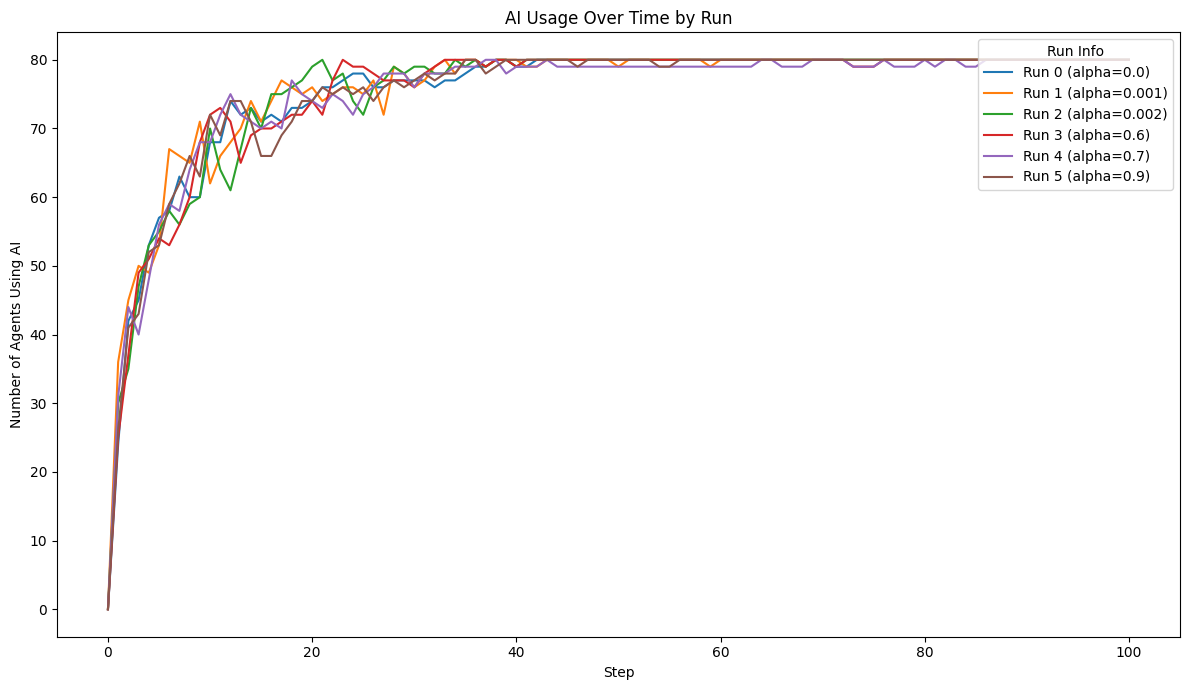

In [57]:

# Boost values for each RunId
boosts = [0.0, 0.001, 0.002, 0.6, 0.7, 0.9]

# List of your dataframes
dataframes = [data_0, data_1, data_2, data_3, data_4, data_5]

plt.figure(figsize=(12, 7))

# Plot each line
for i, df in enumerate(dataframes):
    # Ensure 'Step' is numeric
    df['Step'] = pd.to_numeric(df['Step'])
    df['AI Usage Choice'] = pd.to_numeric(df['AI Usage Choice'])

    # Group by step and sum AI usage
    summed = df.groupby('Step')['AI Usage Choice'].sum().reset_index()

    # Plot the line
    sns.lineplot(data=summed, x='Step', y='AI Usage Choice', label=f'Run {i} (alpha={boosts[i]})')

# Final touches
plt.title('AI Usage Over Time by Run')
plt.xlabel('Step')
plt.ylabel('Number of Agents Using AI')
plt.legend(title='Run Info', loc='upper right')
plt.tight_layout()
plt.show()

/var/folders/cs/r7k4gwfd68jf9d2z5r4s02w40000gn/T/ipykernel_59329/782172779.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Step'] = pd.to_numeric(df['Step'])
/var/folders/cs/r7k4gwfd68jf9d2z5r4s02w40000gn/T/ipykernel_59329/782172779.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Skill'] = pd.to_numeric(df['Skill'])
/var/folders/cs/r7k4gwfd68jf9d2z5r4s02w40000gn/T/ipykernel_59329/782172779.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Tr

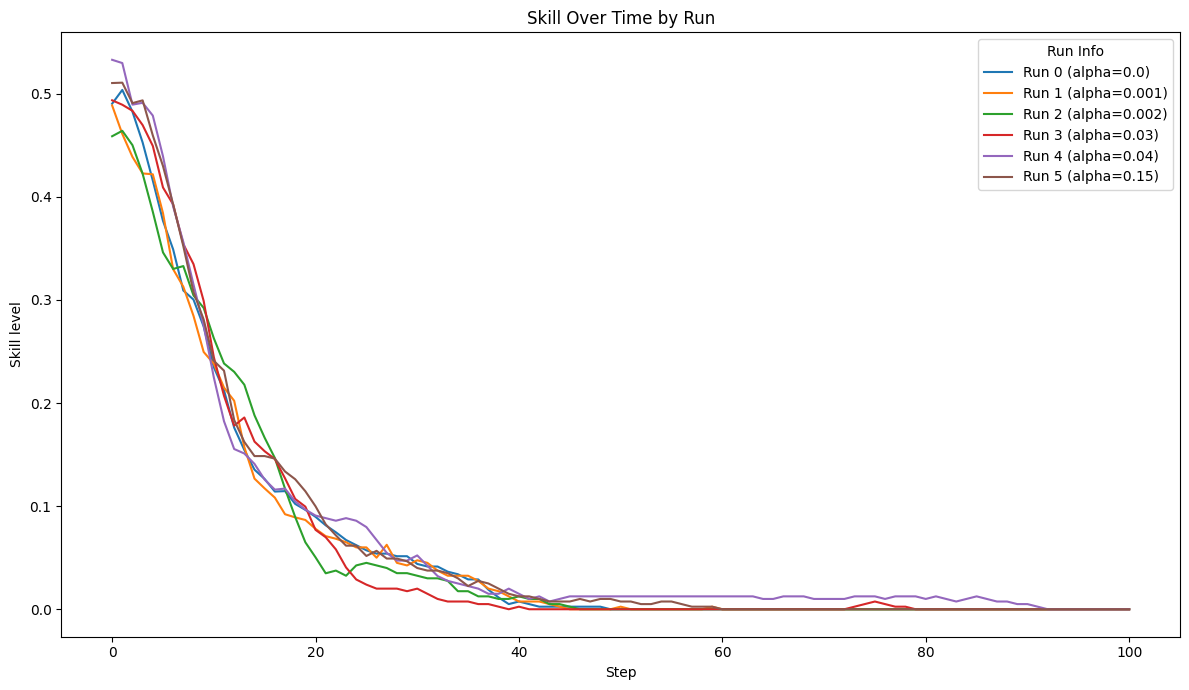

In [58]:

# Boost values for each RunId
boosts = [0.0, 0.001, 0.002, 0.03, 0.04, 0.15]

# List of your dataframes
dataframes = [data_0, data_1, data_2, data_3, data_4, data_5]

plt.figure(figsize=(12, 7))

# Plot each line
for i, df in enumerate(dataframes):
    # Ensure 'Step' is numeric
    df['Step'] = pd.to_numeric(df['Step'])
    df['Skill'] = pd.to_numeric(df['Skill'])

    # Group by step and sum AI usage
    summed = df.groupby('Step')['Skill'].mean().reset_index()

    # Plot the line
    sns.lineplot(data=summed, x='Step', y='Skill', label=f'Run {i} (alpha={boosts[i]})')

# Final touches
plt.title('Skill Over Time by Run')
plt.xlabel('Step')
plt.ylabel('Skill level')
plt.legend(title='Run Info', loc='upper right')
plt.tight_layout()
plt.show()

/var/folders/cs/r7k4gwfd68jf9d2z5r4s02w40000gn/T/ipykernel_59329/4191016953.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Step'] = pd.to_numeric(df['Step'])
/var/folders/cs/r7k4gwfd68jf9d2z5r4s02w40000gn/T/ipykernel_59329/4191016953.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['AI Usage Choice'] = pd.to_numeric(df['AI Usage Choice'])
/var/folders/cs/r7k4gwfd68jf9d2z5r4s02w40000gn/T/ipykernel_59329/4191016953.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sli

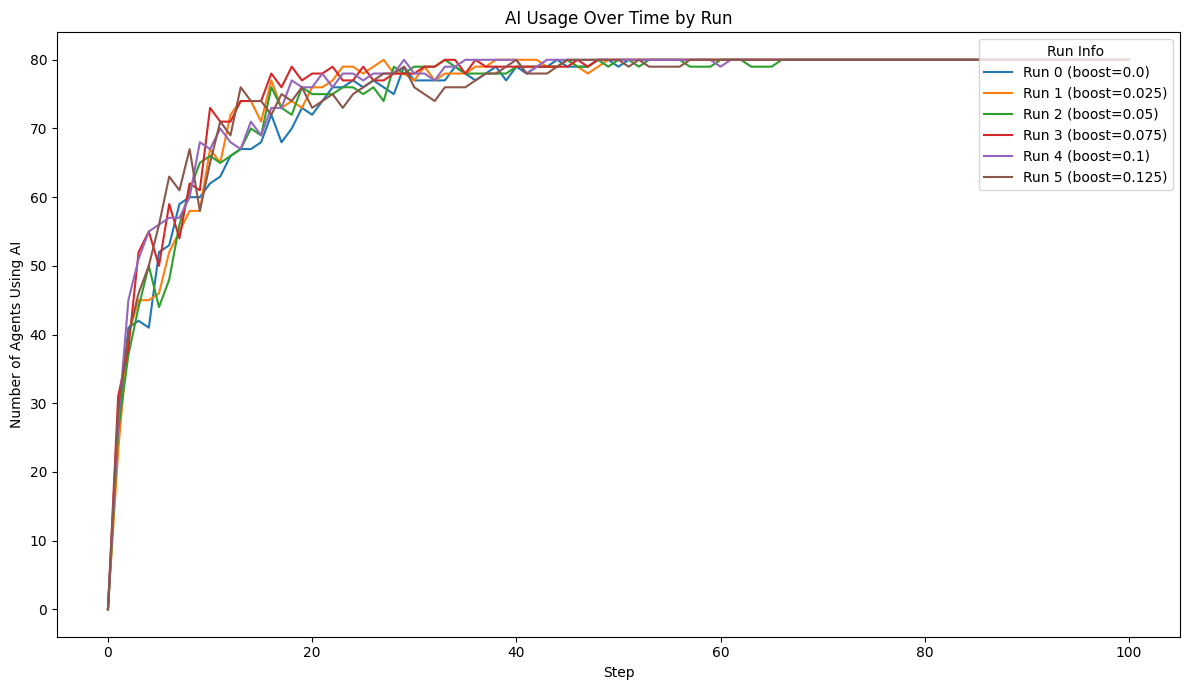

In [51]:

# Boost values for each RunId
boosts = [0.0, 0.025, 0.05, 0.075, 0.1, 0.125]

# List of your dataframes
dataframes = [data_0, data_1, data_2, data_3, data_4, data_5]

# Set up the plot
plt.figure(figsize=(12, 7))

# Plot each line
for i, df in enumerate(dataframes):
    # Ensure 'Step' is numeric
    df['Step'] = pd.to_numeric(df['Step'])
    df['AI Usage Choice'] = pd.to_numeric(df['AI Usage Choice'])

    # Group by step and sum AI usage
    summed = df.groupby('Step')['AI Usage Choice'].sum().reset_index()

    # Plot the line
    sns.lineplot(data=summed, x='Step', y='AI Usage Choice', label=f'Run {i} (boost={boosts[i]})')

# Final touches
plt.title('AI Usage Over Time by Run')
plt.xlabel('Step')
plt.ylabel('Number of Agents Using AI')
plt.legend(title='Run Info', loc='upper right')
plt.tight_layout()
plt.show()

In [43]:
data

,RunId,iteration,Step,alpha,AgentID,Skill,Ability,Wins,Losses,AI Usage Choice,Expected,Outcome,Luck
0,0,0,0,0.00,1,0.538342,0.000000,1,1,0,0.5,0,0.000000
1,0,0,0,0.00,2,0.224713,0.000000,1,1,0,0.5,0,0.000000
2,0,0,0,0.00,3,0.486730,0.000000,1,1,0,0.5,0,0.000000
3,0,0,0,0.00,4,0.235888,0.000000,1,1,0,0.5,0,0.000000
4,0,0,0,0.00,5,0.358548,0.000000,1,1,0,0.5,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48475,5,0,100,0.15,76,0.000000,0.240311,17,44,1,1.0,1,0.040311
48476,5,0,100,0.15,77,0.000000,0.200000,19,47,1,1.0,1,0.000000
48477,5,0,100,0.15,78,0.000000,0.210486,19,35,1,1.0,1,0.010486
48478,5,0,100,0.15,79,0.000000,0.261468,13,32,1,1.0,1,0.061468


In [ ]:
sns.scatterplot(data=data, x='Wins', y='Losses', hue='AI Usage Choice', palette='viridis')

In [ ]:
plt.figure(figsize=(10, 6))

# Loop through each runId from 0 to 5 and plot the line
for run_id in range(6):
    run_data = data[data['RunId'] == run_id]
    sns.lineplot(x='Step', y='boost', data=run_data, label=f'Run {run_id}')

plt.title('Boost per Step for Each Run')
plt.xlabel('Step')
plt.ylabel('Boost')
plt.legend(title='RunId')
plt.grid(True)
plt.tight_layout()
plt.show()

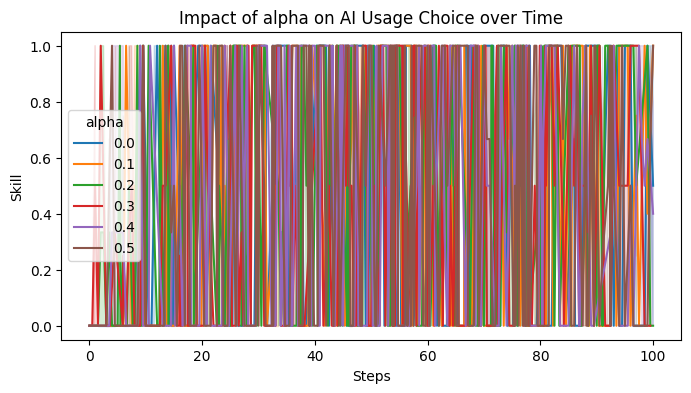

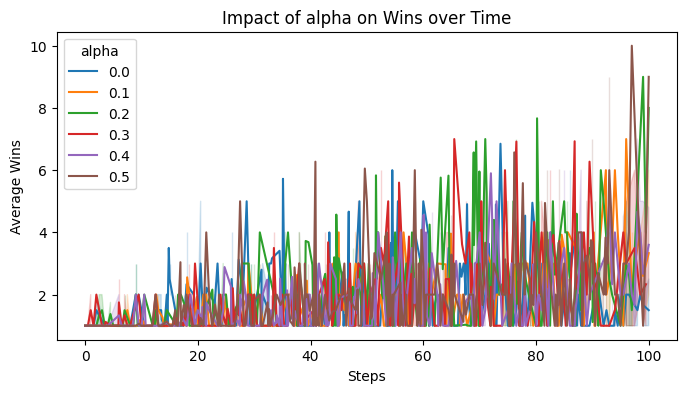

In [23]:
g = sns.lineplot(
    data=agg_results_df, 
    x="Step", 
    y="Wins",  # Plotting Wins over time
    hue="alpha", 
    palette="tab10"
)
g.figure.set_size_inches(8, 4)
g.set(
    title="Impact of alpha on Wins over Time",
    xlabel="Steps",
    ylabel="Average Wins"
)
plt.show()

In [ ]:
# Calculate the mean of the wealth and the number of consecutive rounds
# for all agents in each episode.
agg_results_df = (
    data.groupby(["iteration", "AI Usage Choice", "Skill"])
    .agg({"AI Usage Choice": "mean", "Skill": "mean"})
    .reset_index()
)
agg_results_df.head(3)

AttributeError: 'SeriesGroupBy' object has no attribute 'means'